# Memory记忆存储

## 记忆存储
大语言模型本质上是经过大量数据训练出来的自然语言模型，用户给出输入信息，大语言模型会根据训练的数据进行预测给出指定的结果，大语言模型本身是“无状态的”，模型本身是不会记忆任何上下文的，只能依靠用户本身的输入去产生输出。

当我们使用 langchain 和大语言模型聊天时，会出现如下的情况：

In [2]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

In [3]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_deepseek import ChatDeepSeek

# 初始化Deepseek聊天模型，使用deepseek-chat模型
llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

prompt = PromptTemplate.from_template(
    "请回答我的问题：{question}"
)
# 创建字符串输出解析器
parser = StrOutputParser()

# 构建链式调用
chain = prompt | llm | parser

# 执行链式调用
print(chain.invoke({"question": "记住今天天气是晴天"}))
print(chain.invoke({"question": "今天天气怎么样?"}))

好的，我已记住：今天的天气是晴天。☀️ 如果后续需要查询其他日期的天气或需要帮助，随时告诉我！
抱歉，我无法实时获取您当前所在位置的天气信息。建议您打开手机上的天气应用，或直接搜索“今日天气”加上您所在的城市名称，就能获得准确的实时天气情况。如果您告诉我城市名称，我可以帮您查询近期的天气预报趋势。


前一轮对话告诉大语言模型的信息，下一轮就被“遗忘了”。但如果我们使用使用 Deepseek 聊天时，它能记住多轮对话中的内容，这Deepseek网页版实现了历史记忆功能。

## 实现原理
实现这个记忆功能，就需要额外的模块去保存我们和模型对话的上下文信息，然后在下一次请求时，把

所有的历史信息都输入给模型，让模型输出最终结果。一个记忆组件要实现的三个最基本功能：

- 读取记忆组件保存的历史对话信息
- 写入历史对话信息到记忆组件
- 存储历史对话消息

在LangChain中，提供这个功能的模块就称为 Memory(记忆) ，用于存储用户和模型交互的历史信息。给大语言模型添加记忆功能的方法如下：

- 在链执行前，将历史消息从记忆组件读取出来，和用户输入一起添加到提示词中，传递给大语言模型。
- 在链执行完毕后，将用户的输入和大语言模型输出，一起写入到记忆组件中
- 下一次调用大语言模型时，重复这个过程。
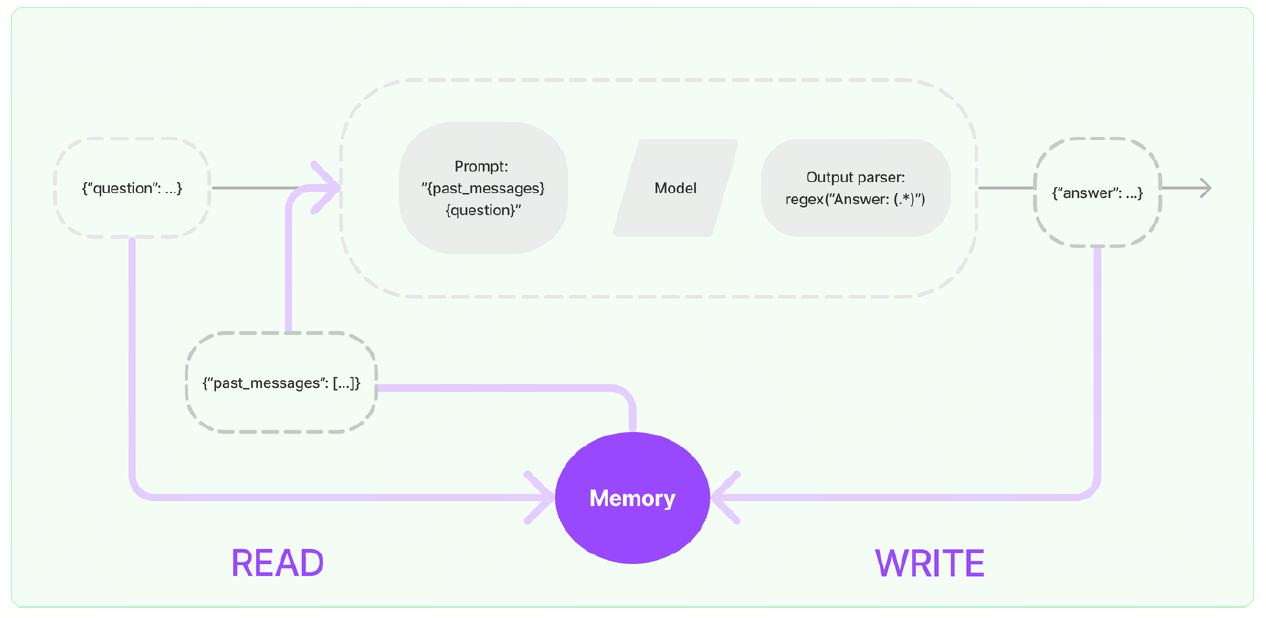

## 实现类介绍
ConversationChain 是 LangChain 早期用于简化对话管理的类，内部集成了内存（如 ConversationBufferMemory）和提示模板，适合快速构建简单对话应用。然而，它存在以下问题：

1. 灵活性不足：提示模板和内存管理逻辑较为固定，难以支持复杂对话流程。
2. 与新 API 不兼容：未针对现代聊天模型（如支持工具调用的模型）优化。
3. 架构过时：LangChain 0.3.x 开始推崇基于 LangChain Expression Language（LCEL）和 Runnable 的模块化设计，ConversationChain 不符合这一理念。在v1.0已经被弃用。

RunnableWithMessageHistory 是 LangChain 推荐的替代方案，优势包括：

1. 模块化：允许自由组合提示模板、模型和内存管理逻辑。
2. 灵活性：支持自定义对话历史存储（如内存、数据库）和复杂对话流程。
3. 兼容性：与 LCEL 和现代聊天模型无缝集成。
4. 长期支持：在 LangChain 0.3.x 中稳定，且不会在 1.0 中移除。

官方建议：

- 简单聊天：用 BaseChatMessageHistory + RunnableWithMessageHistory
- 复杂场景：用 LangGraph persistence（Checkpointer + Content Blocks + 记忆中间件）

## BaseChatMessageHistory简介
BaseChatMessageHistory是用来保存聊天消息历史的抽象基类，下面对BaseChatMessageHistory的核心属性与方法进行分析：

**属性**
- messages: List[BaseMessage]：用来接收和读取历史消息的只读属性

**方法**
- add_messages：批量添加消息，默认实现是每个消息都去调用一次add_message

- add_message：单独添加消息，实现类必须重写这个方法，否则会抛出异常

- clear()：清空所有消息，实现类必须重写这个方法

**常见实现类**

分析LangChain源码可知，在 LangChain 的类结构中，顶层基类是 BaseChatMemory，用于 控制“什么时候加载记忆、什么时候写入”等核心功能， 是所有“聊天记忆类”的抽象基类，定义了统一接口。其职责不是存储数据，而是 协调数据读写，而 InMemoryChatMessageHistory 是具体实现，定义了 “记忆存在哪、怎么存”。
下面是LangChain中常用的消息历史组件以及它们的特性，其中InMemoryChatMessageHistory是BaseChatMemory默认使用的聊天消息历史组件。

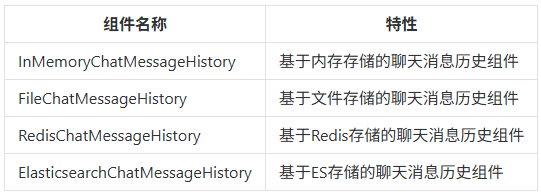

## 实践使用
InMemoryChatMessageHistory 是 LangChain 中的一个内存型消息历史记录器，用于在对话过程中临时存储 AI 和用户之间的消息记录。接下来通过一个简单的示例演示如果使用：

In [4]:
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 初始化Deepseek聊天模型，使用deepseek-chat模型
llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 创建内存聊天历史记录实例，用于存储对话消息
history = InMemoryChatMessageHistory()

# 添加用户消息到聊天历史记录
history.add_user_message("你好，我的爱好是学习")

# 调用语言模型处理聊天历史中的消息
ai_message = llm.invoke(history.messages)

# 记录并输出AI回复的内容
logger.info(f"第一次回答\n{ai_message.content}")

# 将AI回复添加到聊天历史记录中
history.add_message(ai_message)

# 添加新的用户消息到聊天历史记录
history.add_user_message("我叫什么？我的爱好是什么？")

# 再次调用语言模型处理更新后的聊天历史
ai_message2 = llm.invoke(history.messages)

# 记录并输出第二次AI回复的内容
logger.info(f"第二次回答\n{ai_message2.content}")

# 将第二次AI回复添加到聊天历史记录中
history.add_message(ai_message2)

# 遍历并输出所有聊天历史记录中的消息内容
for message in history.messages:
    logger.info(message.content)

INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:第一次回答
你好！很高兴听到你喜欢学习——这真是一个既有趣又充满力量的爱好。学习不仅能让我们不断发现新世界，还能让内心变得更丰富、更从容。

不知道你最近在学习什么领域的内容呢？是语言、编程、历史、哲学，还是某种技能？或者你更喜欢那种“漫无目的”地探索，比如看纪录片、读杂书、听播客？

如果你愿意分享，我很乐意和你聊聊学习中的收获、困惑，或者推荐一些有趣的学习资源。毕竟，学习最迷人的地方之一，就是可以随时找到同路人。😊
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:第二次回答
根据我们刚才的对话，你还没有告诉我你的名字，所以我暂时不知道你叫什么。不过你提到过你的爱好是**学习**——这是一个非常棒且充满探索乐趣的爱好！😊

如果你愿意告诉我你的名字，我很乐意用名字称呼你。当然，如果你更喜欢保持匿名，也完全没问题～
INFO:root:你好，我的爱好是学习
INFO:root:你好！很高兴听到你喜欢学习——这真是一个既有趣又充满力量的爱好。学习不仅能让我们不断发现新世界，还能让内心变得更丰富、更从容。

不知道你最近在学习什么领域的内容呢？是语言、编程、历史、哲学，还是某种技能？或者你更喜欢那种“漫无目的”地探索，比如看纪录片、读杂书、听播客？

如果你愿意分享，我很乐意和你聊聊学习中的收获、困惑，或者推荐一些有趣的学习资源。毕竟，学习最迷人的地方之一，就是可以随时找到同路人。😊
INFO:root:我叫什么？我的爱好是什么？
INFO:root:根据我们刚才的对话，你还没有告诉我你的名字，所以我暂时不知道你叫什么。不过你提到过你的爱好是**学习**——这是一个非常棒且充满探索乐趣的爱好！😊

如果你愿意告诉我你的名字，我很乐意用名字称呼你。当然，如果你更喜欢保持匿名，也完全没问题～


### LCEL调用
通过 RunnableWithMessageHistory 我们可以把任意 Runnable包装起来，并结合 InMemoryChatMessageHistory 来实现多轮对话。

In [5]:
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import RunnableWithMessageHistory, RunnableConfig
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 定义 Prompt
prompt = ChatPromptTemplate.from_messages([
    MessagesPlaceholder(variable_name="history"),  # 用于插入历史消息
    ("human", "{input}")
])

# 初始化Deepseek聊天模型，使用deepseek-chat模型
llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

parser = StrOutputParser()
# 构建处理链：将提示词模板、语言模型和输出解析器组合
chain = prompt | llm | parser
# 创建内存聊天历史记录实例，用于存储对话历史
history = InMemoryChatMessageHistory()
# 创建带消息历史的可运行对象，用于处理带历史记录的对话
runnable = RunnableWithMessageHistory(
    chain,
    get_session_history=lambda session_id: history,
    input_messages_key="input",  # 指定输入键
    history_messages_key="history"  # 指定历史消息键
)
# 清空历史记录
history.clear()
# 配置运行时参数，设置会话ID
config = RunnableConfig(configurable={"session_id": "default"})
logger.info(runnable.invoke({"input": "我爱好学习。"}, config))
logger.info(runnable.invoke({"input": "我的爱好是什么？"}, config))


d:\miniconda3\envs\llmdemo\lib\site-packages\IPython\core\interactiveshell.py:3579: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:这是一个非常棒的爱好！学习不仅能增长知识、开阔眼界，还能带来持续的成长感和成就感。

如果你愿意分享，我很想知道你最近在学习什么？是某个学科、一项技能、一种语言，还是出于兴趣的探索？

无论你学习什么，这里有几个小建议或许对你有帮助：

1.  **保持好奇心**：把学习当作一场探索，而不是任务。问“为什么”和“如果……会怎样”是很好的起点。
2.  **找到节奏**：不必追求每天学很久，关键是持续。每天专注15-30分钟，效果往往比偶尔突击几小时更好。
3.  **学以致用**：尝试把学到的东西讲给别人听，或者应用到实际生活中。输出是最好的巩固方式。
4.  **享受过程**：遇到困难时，记得学习的初衷是乐趣和成长，而不是完美。

如果你需要学习资源、方法建议，或者只是想聊聊你正在学的东西，我随时都在。祝你学习愉快！
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:root:根据你之前说的“我爱好学习”，你的爱好就是 **学习** 本身。

不过，如果你觉得“学习”这个爱好有点宽泛，想更具体地描述它，可以看看下面这些方向，看看哪个更符合你：

1.  **探索未知**：喜欢接触新知识、新领域，享受从“不知道”到“知道”的过程。
2.  **技能提升**：喜欢通过刻意练习掌握一项新技能（比如编程、乐器、外语、烹饪等）。
3

### 记忆窗口裁剪
记忆裁剪是指在长时间对话中，有选择地保留、压缩或丢弃部分历史消息，以保证模型的推理性能和成本可控。trim_messages 是 LangChain 中提供的一个工具函数，用于从消息列表中裁剪出“最近 N 条”消息。它常用于控制记忆窗口（window memory），比如在你使用 InMemoryChatMessageHistory 时，想要只保留最近几条历史记录，示例代码如下：

In [3]:
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import RunnableConfig
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 初始化Deepseek聊天模型，使用deepseek-chat模型
llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 创建提示模板
prompt = ChatPromptTemplate.from_messages([
    #消息列表的占位符
    MessagesPlaceholder("history"),
    ("human", "{question}")
])

# 存储会话历史
store = {}

# 保留的历史轮数
k = 2


def get_session_history(session_id: str) -> InMemoryChatMessageHistory:
    """获取或创建会话历史"""
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()

    # 自动修剪：只保留最近 k 轮对话（2k 条消息）
    history = store[session_id]
    if len(history.messages) > k * 2:
        # 保留最近的消息
        messages_to_keep = history.messages[-k * 2:]
        history.clear()
        history.add_messages(messages_to_keep)

    return history


# 创建带历史的链
chain = RunnableWithMessageHistory(
    prompt | llm,
    get_session_history,
    input_messages_key="question",
    history_messages_key="history"
)

# 配置
config = RunnableConfig(configurable={"session_id": "demo"})

# 主循环
print("开始对话（输入 'quit' 退出）")
while True:
    question = input("\n输入问题：")
    if question.lower() in ['quit', 'exit', 'q']:
        break

    response = chain.invoke({"question": question}, config)
    print("AI回答:", response.content)

    # 可选：显示当前历史消息数
    history = get_session_history("demo")
    print(f"[当前历史消息数: {len(history.messages)}]")

开始对话（输入 'quit' 退出）


d:\miniconda3\envs\llmdemo\lib\site-packages\IPython\core\interactiveshell.py:3579: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


AI回答: 你好！很高兴为你服务！😊

我注意到你只发了一个“你好”，没有提出具体的问题。不过没关系，我可以帮你做很多事情！比如：

✨ **我能帮你做什么？**
- 📝 **写作辅助**：写文章、报告、邮件、文案等
- 💻 **编程帮助**：代码调试、算法讲解、技术问题解答
- 📚 **学习辅导**：解答学科问题、解释概念、提供学习建议
- 🔍 **信息查询**：查找资料、整理信息、分析数据
- 💡 **创意灵感**：头脑风暴、策划方案、解决问题
- 🌐 **翻译服务**：多语言翻译和润色
- 📊 **数据分析**：处理表格、分析趋势、生成报告

**请告诉我你的具体需求**，我会尽全力帮你解决！无论是工作、学习还是生活中的问题，都可以问我哦～ 

有什么我可以帮你的吗？😊
[当前历史消息数: 2]


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


AI回答: 你好！😊

很高兴再次见到你！看起来你还在打招呼，是不是还在想要问什么问题呢？

别着急，慢慢来～ 你可以告诉我：
- 今天想聊点什么？
- 有什么需要我帮忙的吗？
- 或者只是想打个招呼，随便聊聊？

无论是什么，我都在这里等着你！😊
[当前历史消息数: 4]


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


AI回答: 你好！😊

看起来你还在打招呼呢～ 是不是还在想具体要问什么？没关系，我们可以慢慢来！

你可以随时告诉我：
- 想聊什么话题？
- 需要什么帮助？
- 或者只是想测试一下我是否在线？

我随时都在，等你开口！😊
[当前历史消息数: 4]


### Redis存储
使用内存管理消息记录的方式只是临时使用，在实际生产环境都需要持久化的存储数据库。langchain 提供了很多基于其他存储系统的扩展依赖，例如 redis、kafka、MongoDB 等，具体参考官网：https://python.langchain.ac.cn/docs/integrations/memory/。接下来以 redis 为例演示如何持久化存储历史消息。

部署 redis、安装 pip 包

In [4]:
!docker run -d --name redis-stack -p 6379:6379 -p 8001:8001 redis/redis-stack:latest
!pip install langchain-redis redis

'docker' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
     ---------------------------------------- 2.9/2.9 MB 33.9 MB/s  0:00:00

   ---------------------------------------- 0/8 [jsonpath-ng]
   ---------------------------------------- 0/8 [jsonpath-ng]
   ---------------------------------------- 0/8 [jsonpath-ng]
   ---------------------------------------- 0/8 [jsonpath-ng]
   ---------------------------------------- 0/8 [jsonpath-ng]
   ----- ---------------------------------- 1/8 [redis]
   ----- ---------------------------------- 1/8 [redis]
   ----- ---------------------------------- 1/8 [redis]
   ----- ---------------------------------- 1/8 [redis]
   ----- ---------------------------------- 1/8 [redis]
   ----- ---------------------------------- 1/8 [redis]
   ----- ---------------------------------- 1/8 [redis]
   ----- ---------------------------------- 1/8 [redis]
   ----- ------------------------

In [4]:
from langchain_community.chat_message_histories import RedisChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import RunnableConfig
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# Redis 配置
REDIS_URL = "redis://localhost:6379/0"

# 初始化Deepseek聊天模型，使用deepseek-chat模型
llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 创建提示模板
prompt = ChatPromptTemplate.from_messages([
    MessagesPlaceholder("history"),
    ("human", "{question}")
])

# 保留的历史轮数
k = 2


def get_session_history(session_id: str) -> RedisChatMessageHistory:
    """获取或创建会话历史（使用 Redis）"""
    # 创建 Redis 历史对象
    history = RedisChatMessageHistory(
        session_id=session_id,
        url=REDIS_URL,
        ttl=3600  # 1小时过期
    )

    # 自动修剪：只保留最近 k 轮对话（2k 条消息）
    if len(history.messages) > k * 2:
        # 保留最近的消息
        messages_to_keep = history.messages[-k * 2:]
        history.clear()
        history.add_messages(messages_to_keep)

    return history


# 创建带历史的链
chain = RunnableWithMessageHistory(
    prompt | llm,
    get_session_history,
    input_messages_key="question",
    history_messages_key="history"
)

# 配置
config = RunnableConfig(configurable={"session_id": "demo"})

# 主循环
print("开始对话（输入 'quit' 退出）")
while True:
    question = input("\n输入问题：")
    if question.lower() in ['quit', 'exit', 'q']:
        break

    response = chain.invoke({"question": question}, config)
    logger.info(f"AI回答:{response.content}")

    # 可选：显示当前历史消息数
    history = get_session_history("demo")
    logger.info(f"[当前历史消息数: {len(history.messages)}]")

开始对话（输入 'quit' 退出）


d:\miniconda3\envs\llmdemo\lib\site-packages\IPython\core\interactiveshell.py:3579: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


ConnectionError: Error 10061 connecting to localhost:6379. 由于目标计算机积极拒绝，无法连接。.